In [1]:
import seaborn as sns
import pandas as pd
import numpy as np
import numpy as np
import matplotlib.pyplot as plt

data = sns.load_dataset("penguins").dropna().values
df = pd.DataFrame(data, columns=["especie", "isla", "longitud_pico (mm)", "profundidad_pico (mm)", "longitud_aleta (mm)", "masa_corporal (g)", "genero"])

df[:5]


,especie,isla,longitud_pico (mm),profundidad_pico (mm),longitud_aleta (mm),masa_corporal (g),genero
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
4,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male


Esto cargará un dataframe (df), usando la librería seaborn, con algunas características morfológicas y geográficas de diferentes especies de pingüinos. Las colujmnas contienen los siguientes datos:

```
[especie, isla, longitud del pico, profundidad del pico, longitud de la aleta, masa corporal, genero]
```

## Laboratorio 1.1

1.   ¿Cuáles son las profundidades del pico máxima y mínima de los pinguinos de la isla Torgersen?

2.    ¿De qué isla, especie y género es el pingüino con la mayor masa corporal?
       **Ayuda:** utilice la función `argmax()`

3.   ¿Cuál es la masa corporal media de los pinguinos macho que no son de la especie Gentoo?

4.   Grafique la distribución de la longitud del pico. Añada el valor medio y la desviación estándar en el título de la figura. **Ayuda:** utilice la funcion `hist()`

5.   ¿Cuáles son las islas y especies presentes en el conjunto de datos? ¿Con qué frecuencia aparecen? Grafique la distribución de la masa corporal para los pingüinos.




  



**1. Profundidad del pico máxima y mínima en la isla Torgersen**
Se filtran los pingüinos de la isla Torgersen y se calculan los estadísticos.

In [2]:
torgersen = df[df["isla"] == "Torgersen"]
max_prof = torgersen["profundidad_pico (mm)"].max()
min_prof = torgersen["profundidad_pico (mm)"].min()
print(f"Máxima profundidad del pico en Torgersen: {max_prof} mm")
print(f"Mínima profundidad del pico en Torgersen: {min_prof} mm")

Máxima profundidad del pico en Torgersen: 21.5 mm
Mínima profundidad del pico en Torgersen: 15.9 mm


**2. Pingüino con mayor masa corporal**
Se usa idxmax() para encontrar la fila con mayor masa corporal y se extrae la información.

In [3]:
idx_max_masa = df["masa_corporal (g)"].idxmax()
pinguino_max = df.loc[idx_max_masa]
print(f"Isla: {pinguino_max['isla']}")
print(f"Especie: {pinguino_max['especie']}")
print(f"Género: {pinguino_max['genero']}")
print(f"Masa corporal: {pinguino_max['masa_corporal (g)']} g")

Isla: Biscoe
Especie: Gentoo
Género: Male
Masa corporal: 6300.0 g


**3. Masa corporal media de los pingüinos macho que no son de la especie Gentoo**
Se filtra por género "Macho" y especie diferente a "Gentoo", luego se calcula la media.

In [4]:
machos_no_gentoo = df[(df["genero"] == "Male") & (df["especie"] != "Gentoo")]
media_masa = machos_no_gentoo["masa_corporal (g)"].mean()
print(f"Masa corporal media (machos no Gentoo): {media_masa:.1f} g")

Masa corporal media (machos no Gentoo): 4010.3 g


**4. Histograma de la longitud del pico con media y desviación estándar en el título**
Se extrae la columna "longitud_pico (mm)", se calcula la  media y desviación estándar, y se genera el gráfico.

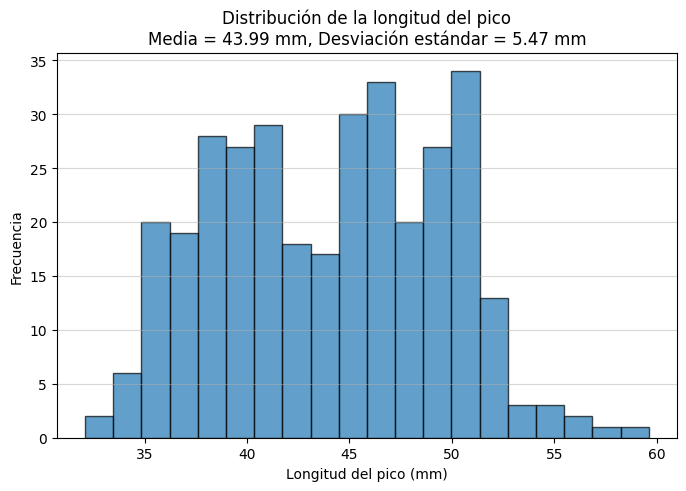

In [5]:
longitud_pico = df["longitud_pico (mm)"]
media = longitud_pico.mean()
std = longitud_pico.std()

plt.figure(figsize=(8,5))
plt.hist(longitud_pico, bins=20, edgecolor='black', alpha=0.7)
plt.title(f'Distribución de la longitud del pico\nMedia = {media:.2f} mm, Desviación estándar = {std:.2f} mm')
plt.xlabel('Longitud del pico (mm)')
plt.ylabel('Frecuencia')
plt.grid(axis='y', alpha=0.5)
plt.show()

**5. Islas y especies presentes con sus frecuencias, y distribución de la masa corporal**

Obtenemos las islas únicas, sus frecuencias, lo mismo para especies, y luego se grafica la distribución de la masa corporal.

Islas y su frecuencia:
isla
Biscoe       163
Dream        123
Torgersen     47
Name: count, dtype: int64

Especies y su frecuencia:
especie
Adelie       146
Gentoo       119
Chinstrap     68
Name: count, dtype: int64


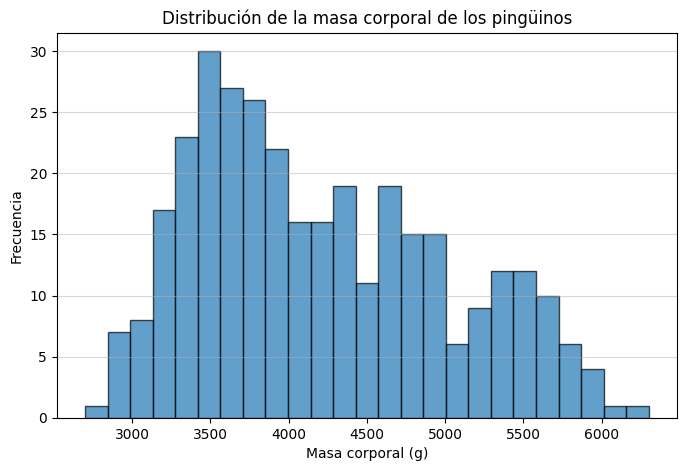

In [6]:
# Frecuencia de islas
islas_freq = df["isla"].value_counts()
print("Islas y su frecuencia:")
print(islas_freq)

# Frecuencia de especies
especies_freq = df["especie"].value_counts()
print("\nEspecies y su frecuencia:")
print(especies_freq)

# Gráfico de distribución de masa corporal
plt.figure(figsize=(8,5))
plt.hist(df["masa_corporal (g)"], bins=25, edgecolor='black', alpha=0.7)
plt.title('Distribución de la masa corporal de los pingüinos')
plt.xlabel('Masa corporal (g)')
plt.ylabel('Frecuencia')
plt.grid(axis='y', alpha=0.5)
plt.show()